In [1]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler, Normalizer

In [2]:
# Генерация данных из экспоненциального распределения
np.random.seed(42)
data = np.random.exponential(scale=2, size=1000)

# Стандартизация данных (приведение к среднему 0 и стандартному отклонению 1)
scaler = StandardScaler()
data_standardized = scaler.fit_transform(data.reshape(-1, 1)).flatten()

## Тест Колмогорова-Смирнова

In [7]:
# Проведение теста Колмогорова-Смирнова на нормальность
statistic, p_value = stats.kstest(data_standardized, 'norm')

# Вывод результатов теста
print(f"Статистика теста: {statistic:.4f}")
print(f"p-значение: {p_value:.4f}")

# Интерпретация результатов
alpha = 0.05
if p_value < alpha:
    print("Отклоняем H0: данные не распределены нормально.")
else:
    print("Не отклоняем H0: данные можно считать нормально распределенными.")


Статистика теста: 0.1597
p-значение: 0.0000
Отклоняем H0: данные не распределены нормально.


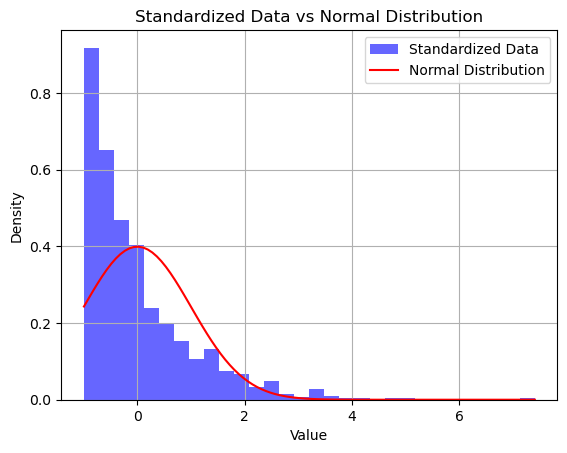

In [4]:
# Визуализация
plt.hist(data_standardized, bins=30, density=True, alpha=0.6, color='b', label="Standardized Data")
x = np.linspace(min(data_standardized), max(data_standardized), 100)
plt.plot(x, stats.norm.pdf(x), 'r-', label='Normal Distribution')
plt.xlabel('Value')
plt.ylabel('Density')
plt.title('Standardized Data vs Normal Distribution')
plt.legend()
plt.grid()
plt.show()

## Тест Шапиро-Уилка

In [5]:
# Проведение теста Шапиро-Уилка на нормальность
statistic, p_value = stats.shapiro(data_standardized)

# Вывод результатов теста
print(f"Статистика теста: {statistic:.4f}")
print(f"p-значение: {p_value:.4f}")

# Интерпретация результатов
alpha = 0.05
if p_value < alpha:
    print("Отклоняем H0: данные не распределены нормально.")
else:
    print("Не отклоняем H0: данных достаточно для предположения нормальности распределения.")


Статистика теста: 0.8246
p-значение: 0.0000
Отклоняем H0: данные не распределены нормально.


## Тест Андерсона-Дарлинга

In [6]:
# Проведение теста Андерсона-Дарлинга на нормальность
result = stats.anderson(data_standardized, dist='norm')

# Вывод результатов теста
print("Статистика теста:", result.statistic)
print("Критические значения:", result.critical_values)
print("Уровни значимости:", result.significance_level)

# Интерпретация результатов
alpha = 0.05 * 100  # Преобразуем в проценты для корректного сравнения
if result.statistic > result.critical_values[2]:  # Сравниваем с уровнем 5% (третье значение)
    print("Отклоняем H0: данные не распределены нормально.")
else:
    print("Не отклоняем H0: данных достаточно для предположения нормальности распределения.")


Статистика теста: 46.51960676156841
Критические значения: [0.574 0.653 0.784 0.914 1.088]
Уровни значимости: [15.  10.   5.   2.5  1. ]
Отклоняем H0: данные не распределены нормально.
